# Video title text analysis


## IMPORTS

In [1]:
# !pip install pandas numpy matplotlib scikit-learn wordcloud

import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 60)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

VIDEOS_PATH   = "/Users/oliviarobles/YouTubeCompare/data/processed/videos_cleaned.csv"
CHANNELS_PATH = "/Users/oliviarobles/YouTubeCompare/data/processed/channels.csv"

TOP_N = 25            # items in the keyword/phrase charts
GROUP_ORDER = ["independent", "institutional"]
COLORS = {"independent": "#4C72B0", "institutional": "#C44E52"}

# --- figure output directory ---
from pathlib import Path
VIS_DIR = Path("..") / "visualizations"
VIS_DIR.mkdir(parents=True, exist_ok=True)


## PROCESSING DATA

In [2]:
videos   = pd.read_csv(VIDEOS_PATH)
channels = pd.read_csv(CHANNELS_PATH)

videos = videos.merge(channels[["channel_id", "group_label"]],
                      on="channel_id", how="left")

# Publication year, used in the time-evolution section
videos["year"] = pd.to_datetime(videos["published_at"], errors="coerce").dt.year

print("Videos per group:")
print(videos["group_label"].value_counts())
print("\nYear range:", int(videos['year'].min()), "-", int(videos['year'].max()))

Videos per group:
group_label
institutional    6238
independent      2504
Name: count, dtype: int64

Year range: 2008 - 2025


In [3]:
titles = videos[["video_id", "channel_title", "group_label", "year",
                 "title", "view_count", "like_count",
                 "comment_count", "duration_seconds"]].copy()
titles = titles.dropna(subset=["title", "group_label"])
titles["title"] = titles["title"].astype(str)
print(f"{len(titles):,} titles ready")
titles.head()

8,742 titles ready


,video_id,channel_title,group_label,year,title,view_count,like_count,comment_count,duration_seconds
0,--4MpKow8ro,Stanford,institutional,2011,NExT: Bing Overseas Studies,3119.0,8.0,1.0,127.0
1,--ZfVZbmKbY,Stanford,institutional,2017,Mark Hartney: ARPA-E and Funding R&D of Advanced Energy ...,4314.0,38.0,NaN,3771.0
2,--aYHgPKGIs,ETH Zürich,institutional,2017,ETH Zürich: Bereit?,99700.0,1038.0,17.0,129.0
3,--sBEWfPfKA,Stanford,institutional,2019,Stanford course teaches neuroscience through rock climbing,11831.0,321.0,NaN,200.0
4,--tEYv1A_-Y,Lectures by Walter Lewin. They will make you ♥ Physics.,independent,2018,Update Easy Problem #44,3309.0,143.0,35.0,47.0


## 2. CLEANING DATA



In [4]:
STOPWORDS = set("""
a an the and or but if then else for of to in on at by with from into over under
is are was were be been being am do does did doing have has had having will would
can could should shall may might must this that these those it its it's i you he she
we they them his her their our your my me him us as so than too very just not no nor
about above after again against all also any because before below between both each
few more most other some such only own same up down out off here there when where why
how what which who whom whose vs via per
""".split())

# Low-signal corpus words
EXTRA_STOP = {"lecture", "lectures", "part", "full", "video", "official", "hd"}


CHANNEL_STOP = {"minutephysics","walter", "lewin", "3blue1brown","epfl", "stanford","mit", "massachusetts", "institute", "technology",   "eth", "zurich", "zürich", "rich", "kurzgesagt", "nutshell"}

STOPWORDS |= EXTRA_STOP | CHANNEL_STOP

TOKEN_RE = re.compile(r"[a-z0-9]+(?:'[a-z]+)?")

def tokenize(text, keep_stopwords=False, min_len=2):
    toks = TOKEN_RE.findall(text.lower())
    if keep_stopwords:
        return toks
    return [t for t in toks if t not in STOPWORDS and len(t) >= min_len]

titles["tokens"]     = titles["title"].apply(tokenize)
titles["n_words"]    = titles["title"].apply(lambda t: len(tokenize(t, keep_stopwords=True)))
titles["n_chars"]    = titles["title"].str.len()
titles["clean_text"] = titles["tokens"].apply(" ".join)

# Convenience: a sub-DataFrame per category
by_group = {g: titles[titles["group_label"] == g] for g in GROUP_ORDER}
for g in GROUP_ORDER:
    print(f"{g:<15} {len(by_group[g]):>5} titles")

independent      2504 titles
institutional    6238 titles


## TITLE LENGTH

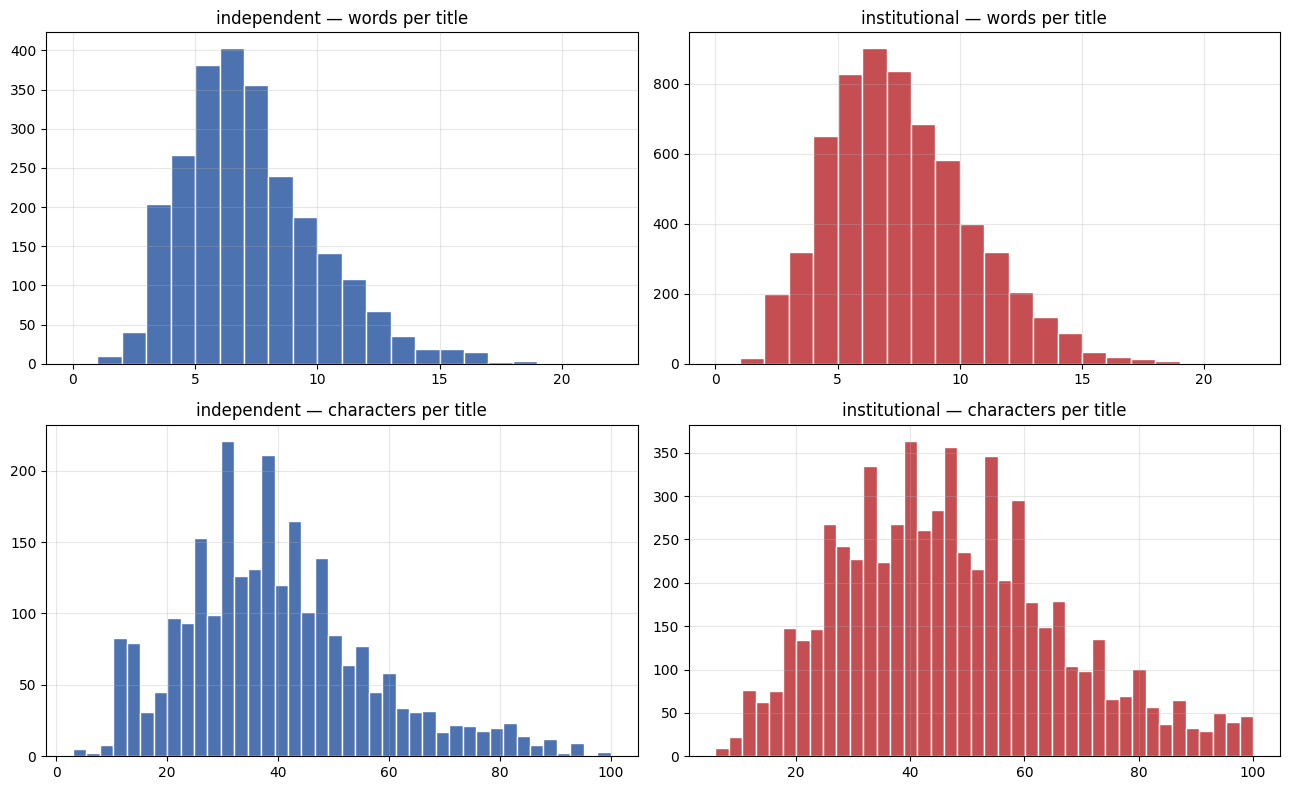

              n_words        n_chars       
                 mean median    mean median
group_label                                
independent       6.8    6.0    39.6   38.0
institutional     7.1    7.0    47.2   45.0


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for j, g in enumerate(GROUP_ORDER):
    d = by_group[g]
    axes[0, j].hist(d["n_words"], bins=range(0, int(titles["n_words"].max()) + 2),
                    color=COLORS[g], edgecolor="white")
    axes[0, j].set_title(f"{g} — words per title")
    axes[1, j].hist(d["n_chars"], bins=40, color=COLORS[g], edgecolor="white")
    axes[1, j].set_title(f"{g} — characters per title")
plt.tight_layout()
plt.savefig(VIS_DIR / "title_length_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

print(titles.groupby("group_label")[["n_words", "n_chars"]]
      .agg(["mean", "median"]).round(1))

## 4. TOP KEYWORDS


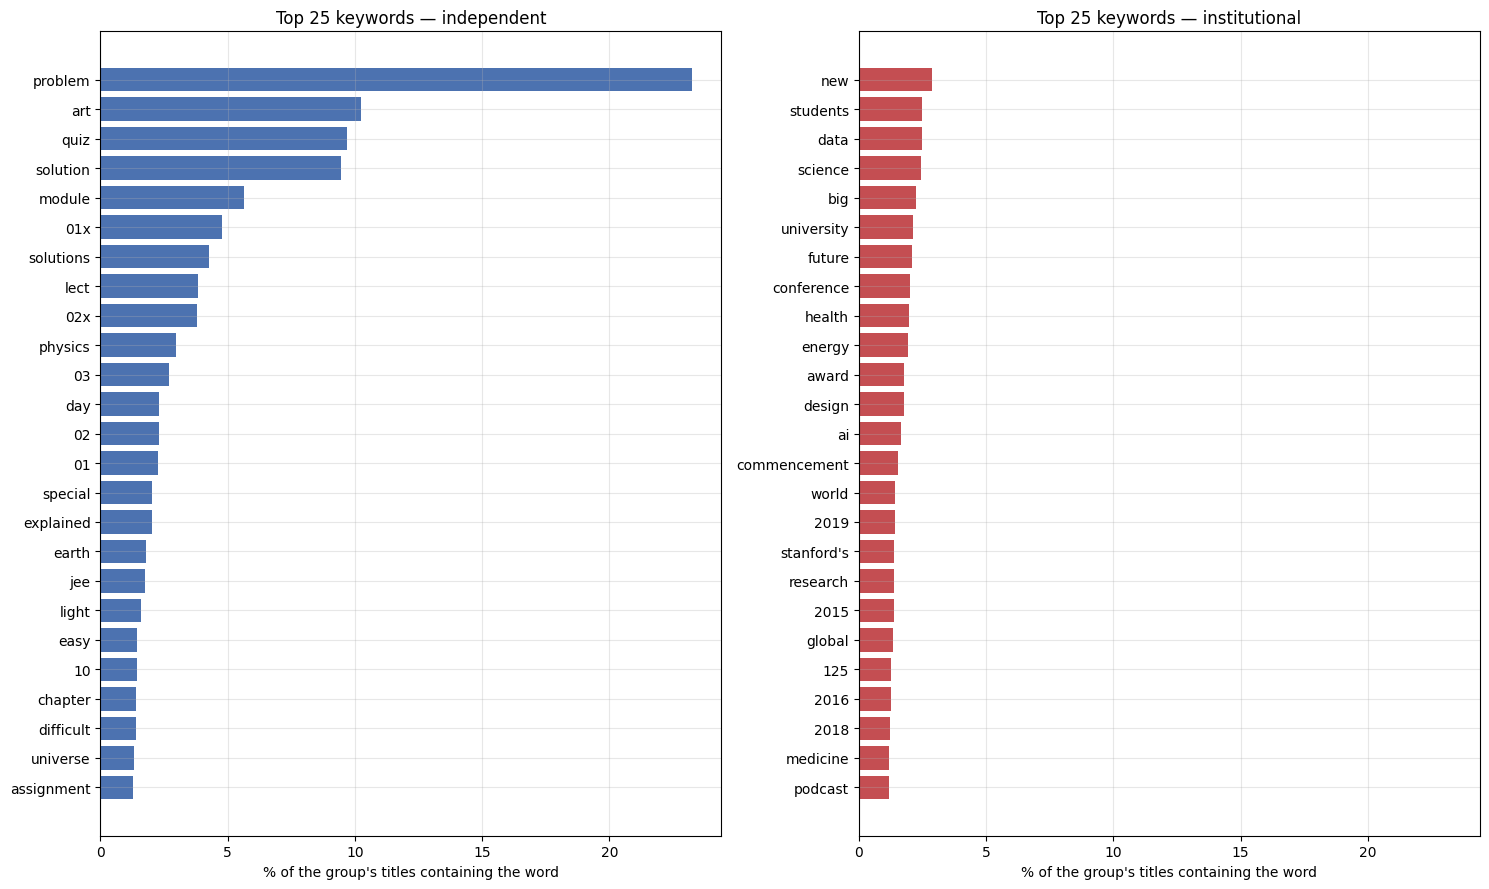

In [6]:
# Token counts per group 
freq = {g: Counter(tok for toks in by_group[g]["tokens"] for tok in toks)
        for g in GROUP_ORDER}

# Doc frequency
n_titles = {g: len(by_group[g]) for g in GROUP_ORDER}
docfreq  = {g: Counter(w for toks in by_group[g]["tokens"] for w in set(toks))
            for g in GROUP_ORDER}

# S% of the group's titles containing the word  (normalized, comparable)
share_pct = {g: {w: 100 * c / n_titles[g] for w, c in docfreq[g].items()}
             for g in GROUP_ORDER}

fig, axes = plt.subplots(1, 2, figsize=(15, 9), sharex=True)
rank_tables = {}
for ax, g in zip(axes, GROUP_ORDER):
    top = sorted(share_pct[g].items(), key=lambda kv: kv[1], reverse=True)[:TOP_N]
    rank_tables[g] = pd.DataFrame(top, columns=["word", "pct_of_titles"])
    words, vals = zip(*top)
    ax.barh(words[::-1], vals[::-1], color=COLORS[g])
    ax.set_title(f"Top {TOP_N} keywords — {g}")
    ax.set_xlabel("% of the group's titles containing the word")
plt.tight_layout()
plt.savefig(VIS_DIR / "top_keywords_by_group.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# normalized ranking
side = pd.concat(
    [rank_tables[g].rename(columns={"word": f"{g}_word",
                                    "pct_of_titles": f"{g}_%titles"}).round(2)
     for g in GROUP_ORDER], axis=1)
side.index = side.index + 1
side.index.name = "rank"
side.head(20)

,independent_word,independent_%titles,institutional_word,institutional_%titles
rank,,,,
1,problem,23.24,new,2.87
2,art,10.22,students,2.48
3,quiz,9.70,data,2.47
4,solution,9.46,science,2.42
5,module,5.63,big,2.24
6,01x,4.79,university,2.13
7,solutions,4.27,future,2.07
8,lect,3.83,conference,2.00
9,02x,3.79,health,1.96


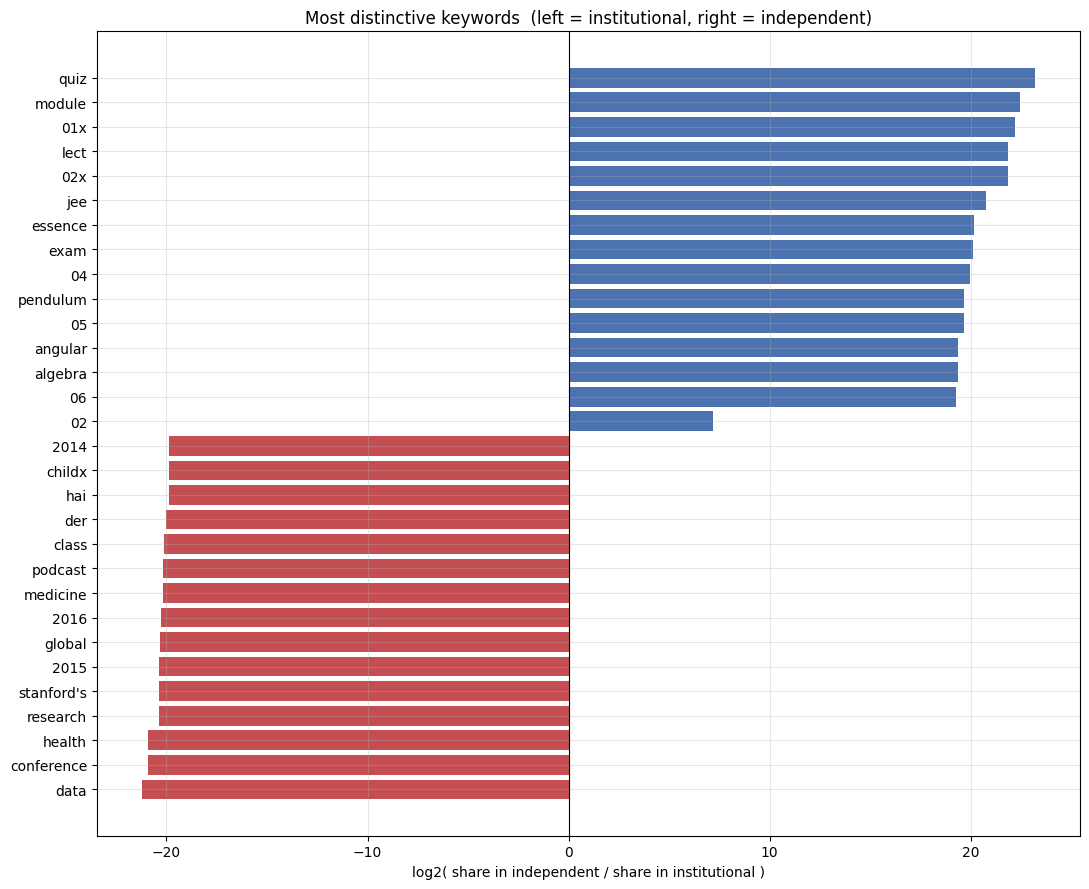

In [8]:
EPS = 1e-6
MIN_TITLES = 15   # word must appear in >= this many titles (across both groups)

g_ind, g_inst = "independent", "institutional"
vocab = set(docfreq[g_ind]) | set(docfreq[g_inst])

rows = []
for w in vocab:
    total_df = docfreq[g_ind].get(w, 0) + docfreq[g_inst].get(w, 0)
    if total_df < MIN_TITLES:
        continue
    s_ind  = share_pct[g_ind].get(w, 0.0)
    s_inst = share_pct[g_inst].get(w, 0.0)
    rows.append({"word": w,
                 "%_independent":  s_ind,
                 "%_institutional": s_inst,
                 "log2_ratio": np.log2((s_ind + EPS) / (s_inst + EPS))})

dist = pd.DataFrame(rows)
top_ind  = dist.sort_values("log2_ratio", ascending=False).head(15)
top_inst = dist.sort_values("log2_ratio").head(15)

fig, ax = plt.subplots(figsize=(11, 9))
combined = pd.concat([top_inst, top_ind]).sort_values("log2_ratio")
bar_colors = [COLORS[g_inst] if v < 0 else COLORS[g_ind] for v in combined["log2_ratio"]]
ax.barh(combined["word"], combined["log2_ratio"], color=bar_colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("log2( share in independent / share in institutional )")
ax.set_title("Most distinctive keywords  (left = institutional, right = independent)")
plt.tight_layout()
plt.savefig(VIS_DIR / "distinctive_keywords_log2ratio.png", dpi=300, bbox_inches="tight")
plt.show()

In [9]:
print("Most distinctive of INDEPENDENT:")
display(top_ind[["word", "%_independent", "%_institutional", "log2_ratio"]].round(2))
print("Most distinctive of INSTITUTIONAL:")
display(top_inst[["word", "%_independent", "%_institutional", "log2_ratio"]].round(2))

Most distinctive of INDEPENDENT:


,word,%_independent,%_institutional,log2_ratio
196,quiz,9.70,0.00,23.21
83,module,5.63,0.00,22.42
200,01x,4.79,0.00,22.19
322,lect,3.83,0.00,21.87
474,02x,3.79,0.00,21.86
257,jee,1.76,0.00,20.74
421,essence,1.16,0.00,20.14
14,exam,1.12,0.00,20.09
114,04,1.04,0.00,19.99
319,05,0.84,0.00,19.68


Most distinctive of INSTITUTIONAL:


,word,%_independent,%_institutional,log2_ratio
457,data,0.0,2.47,-21.24
27,conference,0.0,2.00,-20.93
186,health,0.0,1.96,-20.90
78,research,0.0,1.38,-20.39
39,stanford's,0.0,1.38,-20.39
475,2015,0.0,1.36,-20.38
151,global,0.0,1.33,-20.34
340,2016,0.0,1.25,-20.25
273,medicine,0.0,1.19,-20.18
204,podcast,0.0,1.17,-20.16


## BIGRAMS AND TRIGRAMS 

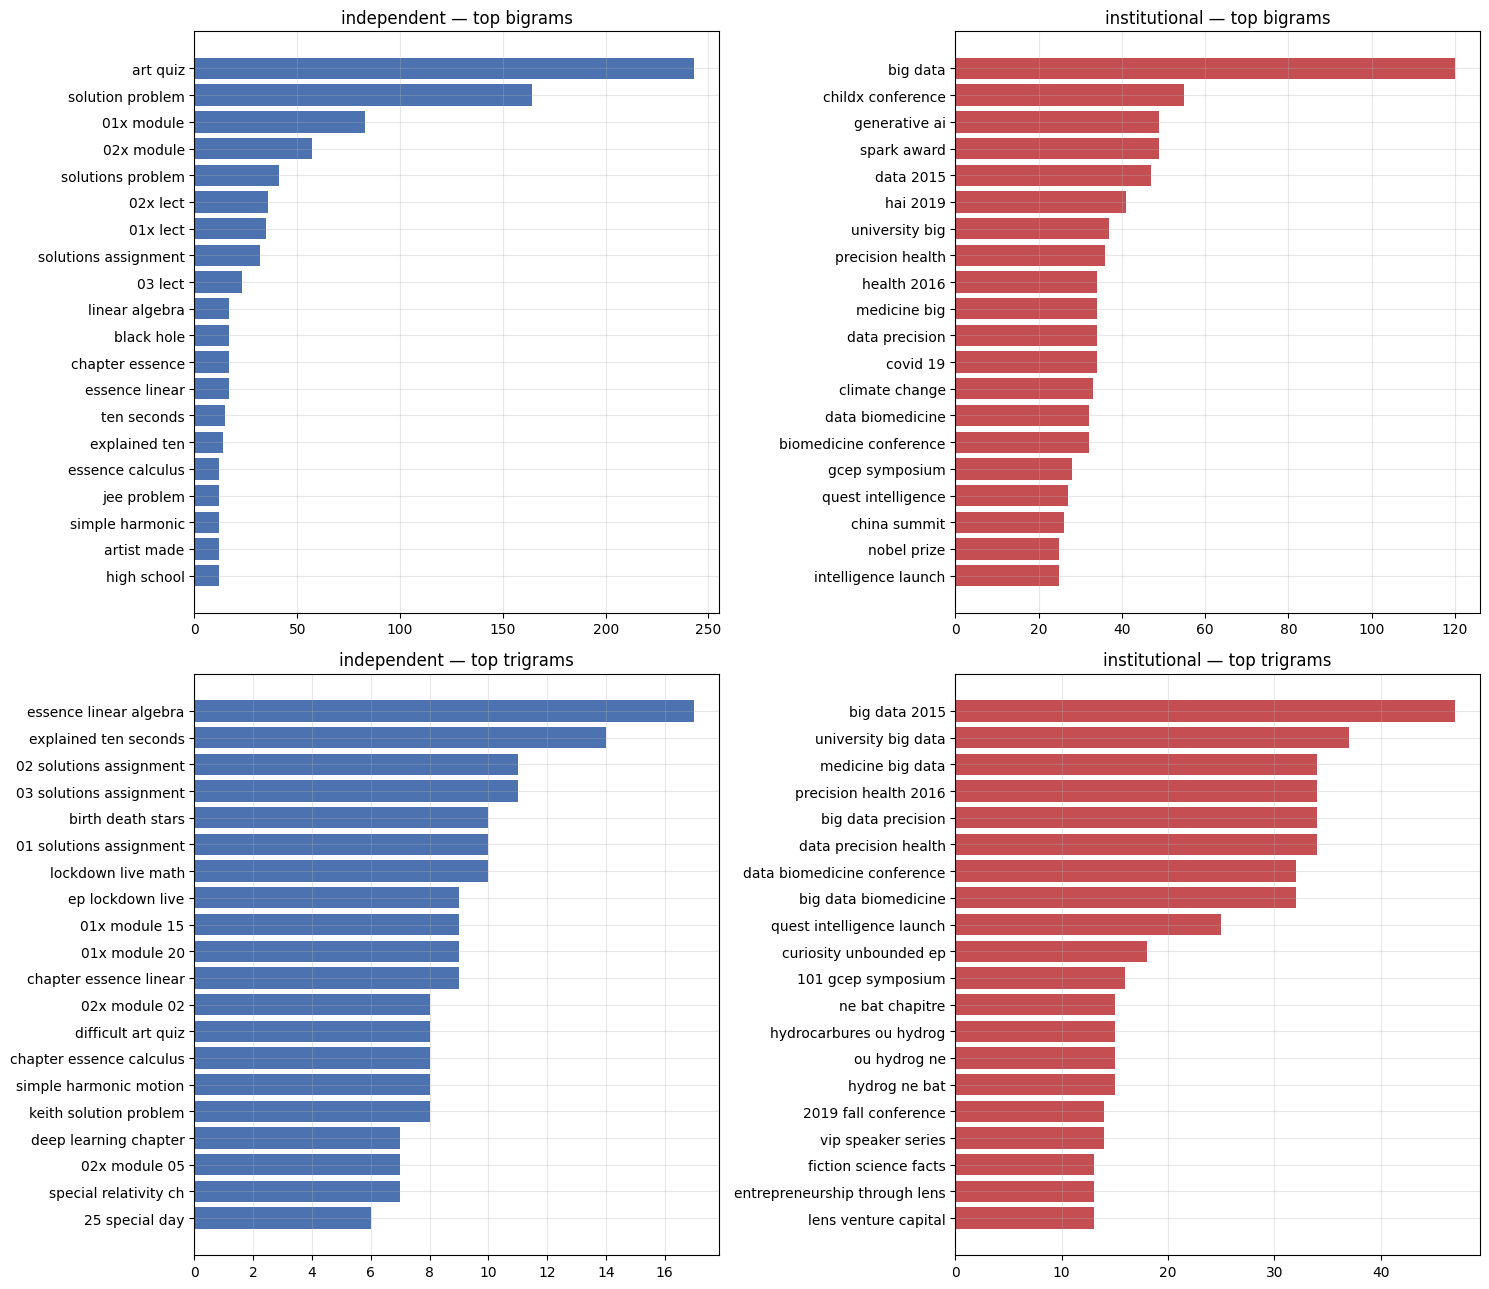

In [10]:
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(text_series, ngram, n=20):
    vec = CountVectorizer(ngram_range=(ngram, ngram), stop_words=list(STOPWORDS))
    X = vec.fit_transform(text_series)
    counts = np.asarray(X.sum(axis=0)).ravel()
    vocab = vec.get_feature_names_out()
    order = counts.argsort()[::-1][:n]
    return pd.DataFrame({"phrase": vocab[order], "count": counts[order]})

fig, axes = plt.subplots(2, 2, figsize=(15, 13))
for j, g in enumerate(GROUP_ORDER):
    bg = top_ngrams(by_group[g]["clean_text"], 2)
    tg = top_ngrams(by_group[g]["clean_text"], 3)
    axes[0, j].barh(bg["phrase"][::-1], bg["count"][::-1], color=COLORS[g])
    axes[0, j].set_title(f"{g} — top bigrams")
    axes[1, j].barh(tg["phrase"][::-1], tg["count"][::-1], color=COLORS[g])
    axes[1, j].set_title(f"{g} — top trigrams")
plt.tight_layout()
plt.savefig(VIS_DIR / "top_bigrams_trigrams.png", dpi=300, bbox_inches="tight")
plt.show()

## TF-IDF

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

per_channel = (titles.groupby(["group_label", "channel_title"])["clean_text"]
               .apply(" ".join))

tfidf = TfidfVectorizer(max_features=5000, stop_words=list(STOPWORDS))
M = tfidf.fit_transform(per_channel)
terms = tfidf.get_feature_names_out()

for g in GROUP_ORDER:
    print(f"\n===== {g.upper()} =====")
    for (grp, ch) in per_channel.index:
        if grp != g:
            continue
        i = list(per_channel.index).index((grp, ch))
        row = M[i].toarray().ravel()
        top = row.argsort()[::-1][:10]
        print(f"  {ch:<52} {', '.join(terms[t] for t in top)}")


===== INDEPENDENT =====
  3Blue1Brown                                          essence, chapter, algebra, linear, calculus, math, lockdown, puzzle, ep, formula
  Kurzgesagt – In a Nutshell                           explained, earth, black, universe, hole, humanity, forever, destroy, nuclear, space
  Lectures by Walter Lewin. They will make you ♥ Physics. quiz, problem, module, art, 01x, solution, lect, 02x, solutions, 03
  minutephysics                                        ten, explained, relativity, physics, seconds, feat, paradox, big, ch, picture

===== INSTITUTIONAL =====
  EPFL                                                 de, la, des, le, les, et, ne, podcasts, un, 50
  ETH Zürich                                           der, award, spark, podcast, die, und, polybahn, science, pitch, alea
  Massachusetts Institute of Technology (MIT)          generative, launch, ai, china, summit, quest, intelligence, community, unbounded, heals
  Stanford                                   

## 8. EVOLUTION TOP KEYWORDS



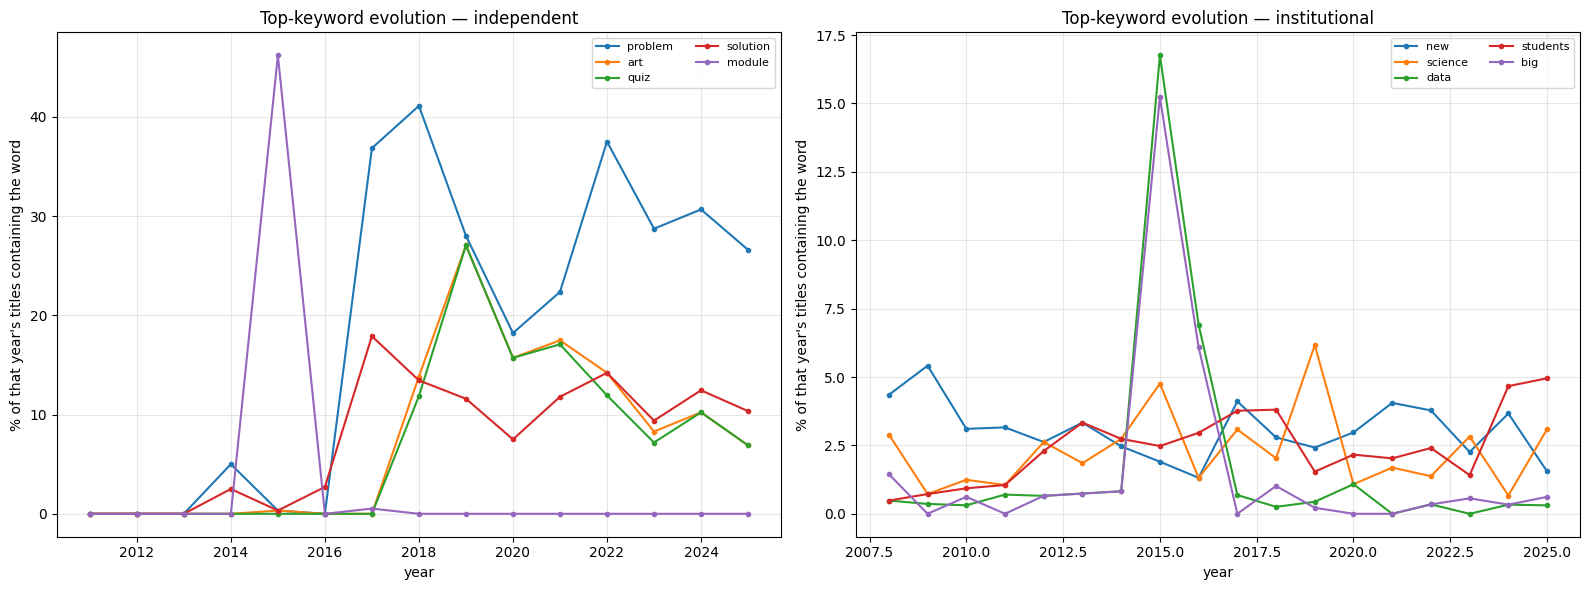

In [12]:
N_TRACK = 5          # keywords to follow per category
MIN_YEAR_VIDEOS = 15 # ignore years with too few videos in that group (noisy)

def keyword_year_share(group_df, word):
    """Fraction of the group's titles in each year whose tokens include `word`."""
    has = group_df["tokens"].apply(lambda toks: word in toks)
    return has.groupby(group_df["year"]).mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
evolution_store = {}
for ax, g in zip(axes, GROUP_ORDER):
    d = by_group[g]
    # restrict to years with enough data
    year_counts = d["year"].value_counts()
    good_years = sorted(y for y, c in year_counts.items() if c >= MIN_YEAR_VIDEOS)
    d = d[d["year"].isin(good_years)]

    track_words = [w for w, _ in freq[g].most_common(N_TRACK)]
    evo = pd.DataFrame(index=good_years)
    for w in track_words:
        s = keyword_year_share(d, w).reindex(good_years).fillna(0)
        evo[w] = s.values
        ax.plot(good_years, evo[w] * 100, marker="o", ms=3, label=w)
    evolution_store[g] = evo
    ax.set_title(f"Top-keyword evolution — {g}")
    ax.set_xlabel("year")
    ax.set_ylabel("% of that year's titles containing the word")
    ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(VIS_DIR / "keyword_evolution_by_group.png", dpi=300, bbox_inches="tight")
plt.show()

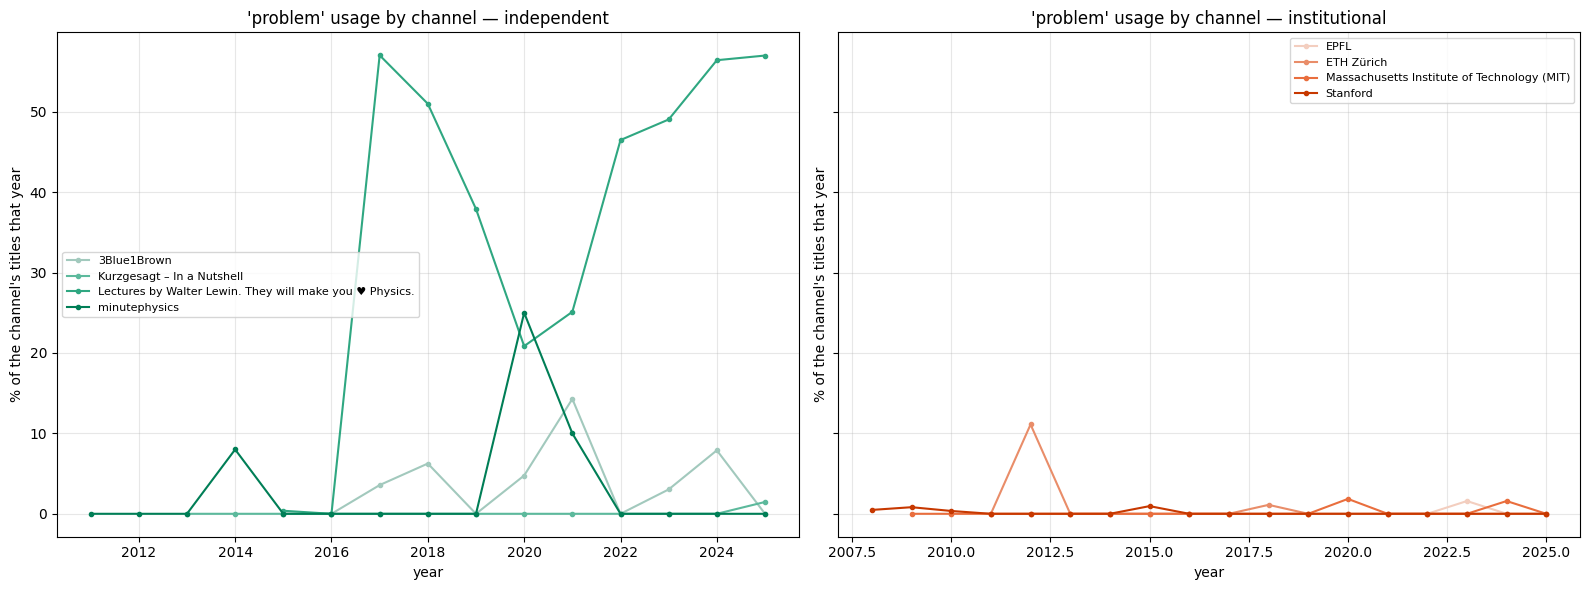

In [13]:

SHADES_INST = {
    "EPFL": "#F3CEBF",
    "ETH Zürich": "#E98D69",
    "Massachusetts Institute of Technology (MIT)": "#E96E3D",
    "Stanford": "#C73800",
}
SHADES_IND = {
    "3Blue1Brown": "#A2C9BD",
    "Kurzgesagt – In a Nutshell": "#5CB99C",
    "Lectures by Walter Lewin. They will make you ♥ Physics.": "#2FA781",
    "minutephysics": "#007E56",
}
CHANNEL_COLORS = {**SHADES_INST, **SHADES_IND}

all_channels = sorted(titles["channel_title"].unique())

KEYWORD = "problem"    

def channel_keyword_share(channel_df, word, years):
    has    = channel_df["tokens"].apply(lambda toks: word in toks)
    share  = has.groupby(channel_df["year"]).mean()
    counts = channel_df.groupby("year").size()
    share  = share.where(counts >= 1)          # NaN where the channel posted nothing
    return share.reindex(years)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, g in zip(axes, GROUP_ORDER):
    d = by_group[g]
    good_years = sorted(y for y, c in d["year"].value_counts().items() if c >= MIN_YEAR_VIDEOS)
    for ch in sorted(d["channel_title"].unique()):
        s = channel_keyword_share(d[d["channel_title"] == ch], KEYWORD, good_years)
        ax.plot(good_years, s.values * 100, marker="o", ms=3,
                color=CHANNEL_COLORS[ch], label=ch)
    ax.set_title(f"'{KEYWORD}' usage by channel — {g}")
    ax.set_xlabel("year"); ax.set_ylabel("% of the channel's titles that year")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(VIS_DIR / "keyword_usage_by_channel.png", dpi=300, bbox_inches="tight")
plt.show()